In [3]:
from datahandler import zarr_to_xarray
zarr_atos = "/scratch/cu0k/ai-ml/datasets/lam-rr-an-oper-0001-mars-5p5km-1984-2020-3h-rmi-v1.zarr"
zarr_lumi = "/scratch/project_465001235/datasets/lam-rr-an-oper-0001-mars-5p5km-1984-2020-3h-rmi-v1.zarr"

In [4]:
#zarr=zarr_atos
zarr=zarr_lumi
ds = zarr_to_xarray(zarr)

/pfs/lustrep4/scratch/project_465001235/vandenbl/anemoi/code/rmai-verification/datahandler.py:96: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds=ds.assign_coords({'time':ds['valid_date'].values})


In [5]:
ds

<xarray.Dataset> Size: 43TB
Dimensions:         (fc_time: 1, valid_time: 106167, y: 1069, x: 1069)
Coordinates:
  * fc_time         (fc_time) object 8B ''
  * y               (y) int64 9kB 0 1 2 3 4 5 ... 1063 1064 1065 1066 1067 1068
  * x               (x) int64 9kB 0 1 2 3 4 5 ... 1063 1064 1065 1066 1067 1068
    longitude       (y, x) float64 9MB dask.array<chunksize=(66, 1069), meta=np.ndarray>
    latitude        (y, x) float64 9MB dask.array<chunksize=(66, 1069), meta=np.ndarray>
  * valid_time      (valid_time) datetime64[ns] 849kB 1984-09-01T03:00:00 ......
Data variables: (12/89)
    10u_10          (fc_time, valid_time, y, x) float32 485GB dask.array<chunksize=(1, 1, 1069, 1069), meta=np.ndarray>
    10v_10          (fc_time, valid_time, y, x) float32 485GB dask.array<chunksize=(1, 1, 1069, 1069), meta=np.ndarray>
    2d_2            (fc_time, valid_time, y, x) float32 485GB dask.array<chunksize=(1, 1, 1069, 1069), meta=np.ndarray>
    2t_2            (fc_time, valid_time, y, x) float32 485GB dask.array<chunksize=(1, 1, 1069, 1069), meta=np.ndarray>
    al              (fc_time, valid_time, y, x) float32 485GB dask.array<chunksize=(1, 1, 1069, 1069), meta=np.ndarray>
    cos_julian_day  (fc_time, valid_time, y, x) float32 485GB dask.array<chunksize=(1, 1, 1069, 1069), meta=np.ndarray>
    ...              ...
    z_50            (fc_time, valid_time, y, x) float32 485GB dask.array<chunksize=(1, 1, 1069, 1069), meta=np.ndarray>
    z_500           (fc_time, valid_time, y, x) float32 485GB dask.array<chunksize=(1, 1, 1069, 1069), meta=np.ndarray>
    z_600           (fc_time, valid_time, y, x) float32 485GB dask.array<chunksize=(1, 1, 1069, 1069), meta=np.ndarray>
    z_700           (fc_time, valid_time, y, x) float32 485GB dask.array<chunksize=(1, 1, 1069, 1069), meta=np.ndarray>
    z_850           (fc_time, valid_time, y, x) float32 485GB dask.array<chunksize=(1, 1, 1069, 1069), meta=np.ndarray>
    z_925           (fc_time, valid_time, y, x) float32 485GB dask.array<chunksize=(1, 1, 1069, 1069), meta=np.ndarray>

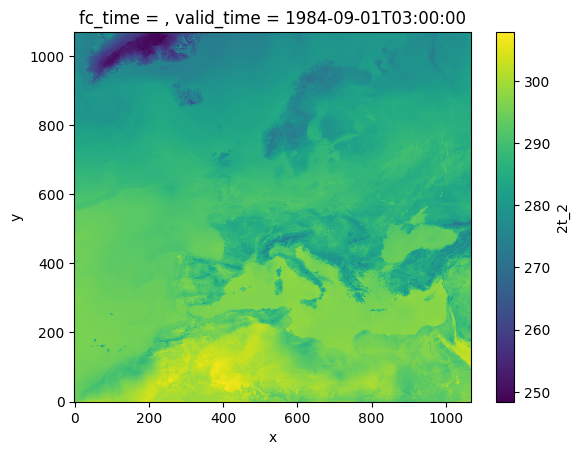

In [9]:
# We can plot in the native projection without knowing what it exactly is
time0=ds.valid_time.values[0]
ds["2t_2"].sel(valid_time=time0).plot()

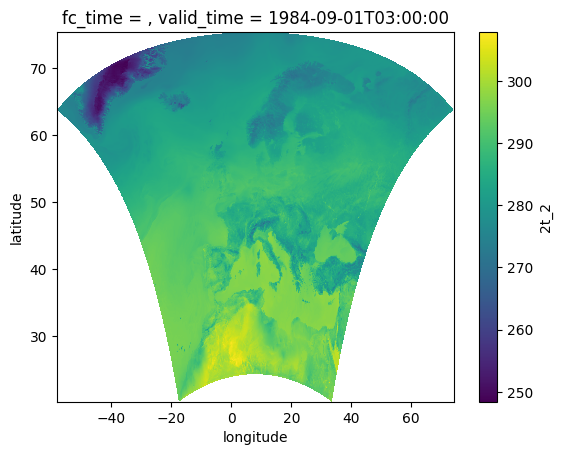

In [11]:
# We can also plot in the PlateCaree projection by 
# specifying the longitudes and latitude as x and y
ds['2t_2'].sel(valid_time=time0).plot(x="longitude",y="latitude")